In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
import pickle
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/sample_data/RTA Dataset.csv')
df.head()


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [4]:
print(f'Nombre de lignes : {df.shape[0]}')
print(f'Nombre de colonnes : {df.shape[1]}')

Nombre de lignes : 12316
Nombre de colonnes : 32


In [5]:
df['Accident_severity'].value_counts()

,count
Accident_severity,
Slight Injury,10415
Serious Injury,1743
Fatal injury,158


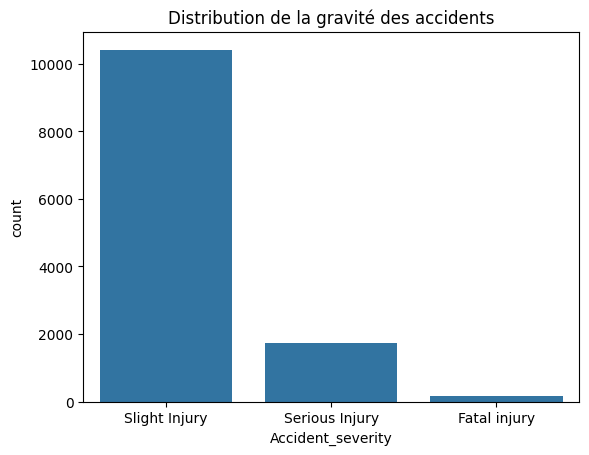

In [6]:
sns.countplot(x='Accident_severity', data=df)
plt.title('Distribution de la gravité des accidents')
plt.show()

In [7]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

,0
Defect_of_vehicle,4427
Service_year_of_vehicle,3928
Work_of_casuality,3198
Fitness_of_casuality,2635
Type_of_vehicle,950
Types_of_Junction,887
Driving_experience,829
Educational_level,741
Vehicle_driver_relation,579
Owner_of_vehicle,482


In [20]:
def fill_missing(df):
    df_clean = df.copy()
    for col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            # Remplir par 'Unknown'
            df_clean[col].fillna('Unknown', inplace=True)
    return df_clean

df_clean = fill_missing(df)
print('Valeurs manquantes après nettoyage :', df_clean.isnull().sum().sum())


Valeurs manquantes après nettoyage : 0


In [21]:
df_clean.to_csv('/content/sample_data/RTA Dataset.csv', index=False)
print('Données nettoyées sauvegardées.')

Données nettoyées sauvegardées.


In [22]:
le_dict = {}
df_encoded = df.copy()
# On enlève la colonne Time car c'est une heure textuelle, on pourrait extraire l'heure mais on va la simplifier
df_encoded.drop('Time', axis=1, inplace=True)

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        le_dict[col] = le
print("✅ Toutes les données textuelles ont été transformées en nombres !")
display(df_encoded.head(3))


✅ Toutes les données textuelles ont été transformées en nombres !


,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,1,0,1,0,0,0,0,3,3,2,...,2,3,2,5,3,7,5,5,9,2
1,1,1,1,4,0,3,11,3,2,2,...,2,3,2,5,3,7,5,5,16,2
2,1,0,1,4,0,0,5,3,6,2,...,2,0,1,1,2,0,5,5,0,1


Découpage Entraînement / Test

> Ajouter une citation



In [23]:
X = df_encoded.drop('Accident_severity', axis=1)
y = df_encoded['Accident_severity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"✅ Taille de l'entraînement : {X_train.shape[0]} accidents.")
print(f"✅ Taille du test (vérification) : {X_test.shape[0]} accidents.")

✅ Taille de l'entraînement : 9852 accidents.
✅ Taille du test (vérification) : 2464 accidents.


Régression Logistique

In [24]:
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print(f"Précision globale (Accuracy) : {accuracy_score(y_test, y_pred_lr):.4f}")
print("\n--- Rapport détaillé : ---")
print(classification_report(y_test, y_pred_lr, zero_division=0))

Précision globale (Accuracy) : 0.8377

--- Rapport détaillé : ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        37
           1       0.00      0.00      0.00       363
           2       0.84      1.00      0.91      2064

    accuracy                           0.84      2464
   macro avg       0.28      0.33      0.30      2464
weighted avg       0.70      0.84      0.76      2464



In [25]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print(f"Précision globale (Accuracy) : {accuracy_score(y_test, y_pred_dt):.4f}")
print("\n--- Rapport détaillé : ---")
print(classification_report(y_test, y_pred_dt, zero_division=0))


Précision globale (Accuracy) : 0.7447

--- Rapport détaillé : ---
              precision    recall  f1-score   support

           0       0.26      0.30      0.28        37
           1       0.24      0.26      0.25       363
           2       0.86      0.84      0.85      2064

    accuracy                           0.74      2464
   macro avg       0.45      0.47      0.46      2464
weighted avg       0.76      0.74      0.75      2464



In [27]:
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"Précision globale (Accuracy) : {accuracy_score(y_test, y_pred_rf):.4f}")
print("\n--- Rapport détaillé : ---")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Précision globale (Accuracy) : 0.8413

--- Rapport détaillé : ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        37
           1       0.91      0.03      0.05       363
           2       0.84      1.00      0.91      2064

    accuracy                           0.84      2464
   macro avg       0.58      0.34      0.32      2464
weighted avg       0.84      0.84      0.77      2464



--- COMPARAISON DES MODELES ---
Régression Logistique : 0.8377
Arbre de Décision     : 0.7447
Random Forest         : 0.8413


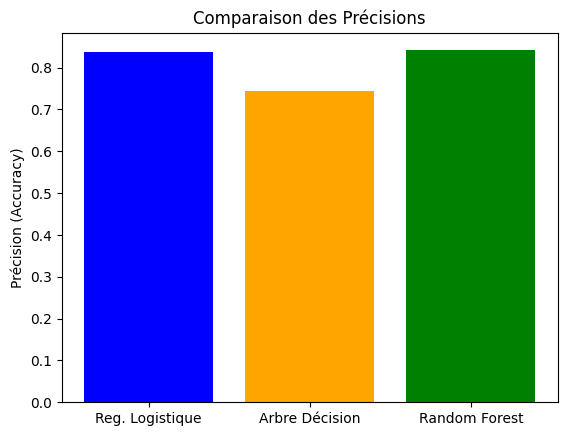

In [28]:
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("--- COMPARAISON DES MODELES ---")
print("Régression Logistique :", round(acc_lr, 4))
print("Arbre de Décision     :", round(acc_dt, 4))
print("Random Forest         :", round(acc_rf, 4))

noms_modeles = ['Reg. Logistique', 'Arbre Décision', 'Random Forest']
scores = [acc_lr, acc_dt, acc_rf]
plt.bar(noms_modeles, scores, color=['blue', 'orange', 'green'])
plt.title("Comparaison des Précisions")
plt.ylabel("Précision (Accuracy)")
plt.show()